# Implementing CNN
In this file I train and use a CNN to predict the numerical results of this problem. In contrary to the MLP, this time my approach should be predicting the next displacement from the recent trajectory since a CNN is designed to exploit local patterns in an ordered signal. So for the CNN experiment I'll turn this into a time-series forecasting problem:<br></br>
$[x(t_{0}), x(t_{1}),..., x(t_{n-1})]$ &rarr; $x(t_{n})$<br></br>
That lets the CNN look at a short history of the oscillator and predict its next displacement. SO instead of giving the CNN a single time value, I'll give it a **window**.

So we're teaching the CNN:

"Look at the recent motion of the system and predict what happens next."

In this case, I'm going to use time series windows of 50 points which correspond to roughly 0.5 seconds of the simulation. Since the time steps are around 0.01 second long.

In [ ]:
# import modules
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# load dataset
data = np.loadtxt("mass_spring_data.csv", delimiter=",", skiprows=1)

t = data[:, 0]
x = data[:, 2]

In [3]:
# create time series window
window_size = 50

# create the sequences
X = []
y = []

for i in range(len(x) - window_size):

    X.append(x[i:i + window_size])
    y.append(x[i + window_size])

# convert into NumPy arrays
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1950, 50)
y shape: (1950,)


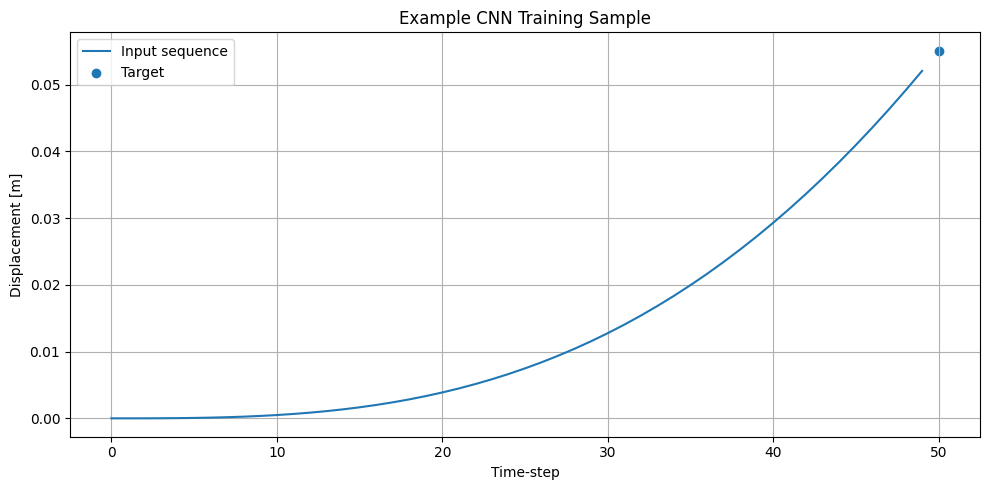

In [8]:
# visualize one training example
plt.figure(figsize=(10, 5))

plt.plot(np.arange(window_size), X[0], label="Input sequence")

plt.scatter(window_size, y[0], label="Target")

plt.xlabel("Time-step")
plt.ylabel("Displacement [m]")
plt.title("Example CNN Training Sample")

plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

In [9]:
# split into training and testing data
split_index = int(0.7 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_test = X[split_index:]
y_test = y[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1365
Testing samples: 585


In [12]:
# convert to pytorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_test = torch.tensor(X_test, dtype=torch.float32)

y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

C:\Users\Asus\AppData\Local\Temp\ipykernel_15560\318386537.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
C:\Users\Asus\AppData\Local\Temp\ipykernel_15560\318386537.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
C:\Users\Asus\AppData\Local\Temp\ipykernel_15560\318386537.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)
C:\Users\Asus\AppData\Local\Temp\ipyker

In [13]:
# add channel
X_train = X_train.unsqueeze(1)
X_test = X_test.unsqueeze(1)

print(X_train.shape)

torch.Size([1365, 1, 50])


In [14]:
# mini batches
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# data loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [16]:
# build the cnn
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5), nn.Tanh(),
        nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5), nn.Tanh(), nn.Flatten(), nn.Linear(32 * 42, 64), nn.Tanh(), nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

In [17]:
# create the model
model = CNN()

print(model)

CNN(
  (network): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,))
    (1): Tanh()
    (2): Conv1d(16, 32, kernel_size=(5,), stride=(1,))
    (3): Tanh()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=1344, out_features=64, bias=True)
    (6): Tanh()
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [18]:
# loss and optimizer
loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [19]:
# train the cnn
epochs = 50

loss_history = []

for epoch in range(epochs):

    model.train()

    total_loss = 0.0

    for X_batch, y_batch in train_loader:

        prediction = model(X_batch)

        loss = loss_function(prediction, y_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = (total_loss / len(train_loader))

    loss_history.append(average_loss)

    if epoch % 5 == 0:

        print(f"Epoch {epoch:3d} | "f"Loss = {average_loss:.8f}")

Epoch   0 | Loss = 0.06784646
Epoch   5 | Loss = 0.00127513
Epoch  10 | Loss = 0.00046862
Epoch  15 | Loss = 0.00020817
Epoch  20 | Loss = 0.00015294
Epoch  25 | Loss = 0.00017952
Epoch  30 | Loss = 0.00011491
Epoch  35 | Loss = 0.00008048
Epoch  40 | Loss = 0.00032801
Epoch  45 | Loss = 0.00007551


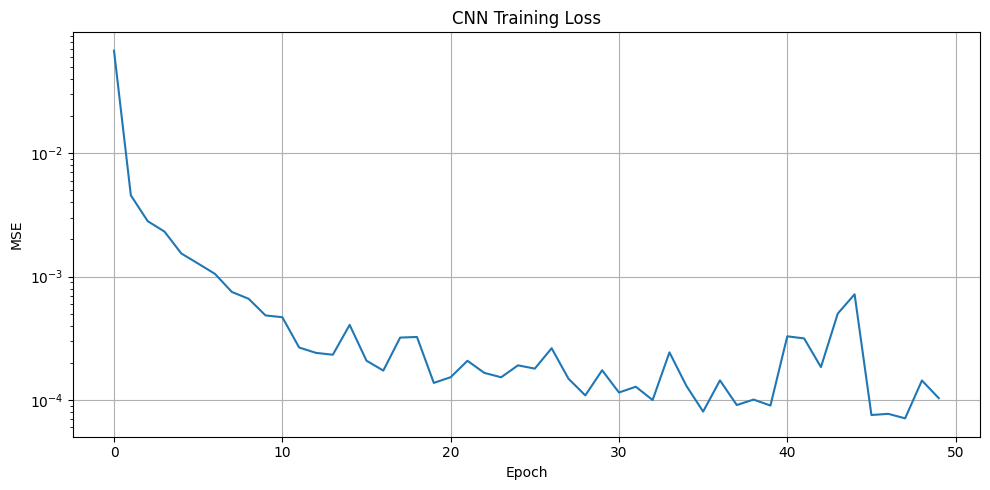

In [20]:
# plot training loss
plt.figure(figsize=(10, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("CNN Training Loss")

plt.yscale("log")
plt.grid()
plt.tight_layout()

plt.show()

In [21]:
# evaluation
model.eval()

predictions = []
actual = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        prediction = model(X_batch)

        predictions.append(prediction.numpy())

        actual.append(y_batch.numpy())

predictions = np.concatenate(predictions).flatten()

actual = np.concatenate(actual).flatten()

In [22]:
# calculate mse and rmse
mse = np.mean((predictions - actual) ** 2)

rmse = np.sqrt(mse)

print()
print("==============================")
print("CNN Performance")
print("==============================")
print(f"MSE  = {mse:.8e}")
print(f"RMSE = {rmse:.8e}")


CNN Performance
MSE  = 4.39955184e-05
RMSE = 6.63291197e-03


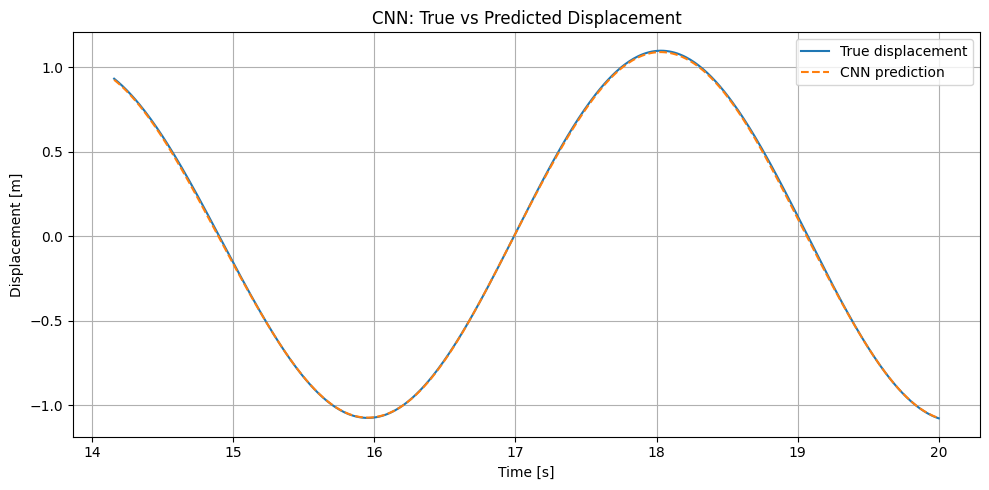

In [23]:
# pot cnn predictions
test_start = split_index + window_size

t_test = t[test_start:]

plt.figure(figsize=(10, 5))

plt.plot(t_test, actual, label="True displacement")

plt.plot(t_test, predictions, "--", label="CNN prediction")

plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.title("CNN: True vs Predicted Displacement")

plt.legend()
plt.grid()
plt.tight_layout()

plt.show()